In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (mean_squared_error, r2_score, mean_absolute_error,
                           accuracy_score, classification_report, confusion_matrix,
                           roc_auc_score, roc_curve)
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Generate features
n_samples = 5000
n_features = 10

# Create feature matrix with different distributions
X = pd.DataFrame()

# Numerical features
X['age'] = np.random.normal(45, 15, n_samples).clip(18, 90)
X['income'] = np.random.exponential(50000, n_samples).clip(20000, 200000)
X['years_experience'] = np.random.gamma(2, 5, n_samples).clip(0, 40)
X['credit_score'] = np.random.normal(650, 100, n_samples).clip(300, 850)
X['debt_to_income'] = np.random.beta(2, 5, n_samples) * 0.5
X['num_dependents'] = np.random.poisson(2, n_samples).clip(0, 8)
X['education_years'] = np.random.choice([10, 12, 14, 16, 18, 20], n_samples, 
                                         p=[0.1, 0.2, 0.3, 0.25, 0.1, 0.05])
X['distance_to_work'] = np.random.gamma(2, 5, n_samples).clip(0, 50)
X['previous_defaults'] = np.random.poisson(0.3, n_samples).clip(0, 3)
X['savings_ratio'] = np.random.beta(2, 8, n_samples)

# Add some noise features
X['noise_1'] = np.random.normal(0, 1, n_samples)
X['noise_2'] = np.random.uniform(-2, 2, n_samples)

print(f"Dataset shape: {X.shape}")
print(f"Features: {list(X.columns)}")
print("\nFirst 5 rows:")
print(X.head())


Dataset shape: (5000, 12)
Features: ['age', 'income', 'years_experience', 'credit_score', 'debt_to_income', 'num_dependents', 'education_years', 'distance_to_work', 'previous_defaults', 'savings_ratio', 'noise_1', 'noise_2']

First 5 rows:
         age        income  years_experience  credit_score  debt_to_income  \
0  18.000000  58595.026026          3.801750    637.505443        0.270480   
1  60.642365  20000.000000          4.527254    651.572625        0.042502   
2  40.701376  43875.672271         14.558123    697.145112        0.125591   
3  51.680216  24698.330757         16.764763    506.697552        0.070771   
4  56.446922  20000.000000         17.171019    658.483783        0.111739   

   num_dependents  education_years  distance_to_work  previous_defaults  \
0               0               14          7.330843                  0   
1               2               16         26.032656                  0   
2               4               18          7.852562              

In [ ]:
# Generate target variable for regression (salary)
salary = (X['age'] * 500 + 
          X['income'] * 0.15 + 
          X['years_experience'] * 2000 + 
          X['credit_score'] * 100 + 
          X['education_years'] * 5000 + 
          X['previous_defaults'] * (-8000) +
          X['savings_ratio'] * 50000 +
          np.random.normal(0, 10000, n_samples))

# Add some non-linear interactions
salary += (X['years_experience'] * X['education_years']) * 200
salary += np.where(X['age'] > 50, 15000, 0)
salary += np.where(X['previous_defaults'] > 0, -5000, 0)

# Ensure positive salary
salary = np.abs(salary).clip(20000, 200000)

y_reg = salary

print(f"\nTarget variable (Salary) statistics:")
print(f"Mean: ${y_reg.mean():,.2f}")
print(f"Std: ${y_reg.std():,.2f}")
print(f"Min: ${y_reg.min():,.2f}")
print(f"Max: ${y_reg.max():,.2f}")


Target variable (Salary) statistics:
Mean: $193,986.46
Std: $12,703.19
Min: $93,250.86
Max: $200,000.00


In [6]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

print(f"\nTraining set size: {X_train_reg.shape[0]}")
print(f"Test set size: {X_test_reg.shape[0]}")



Training set size: 4000
Test set size: 1000


In [7]:
xgb_reg = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

In [8]:
xgb_reg.fit(X_train_reg, y_train_reg, 
            eval_set=[(X_test_reg, y_test_reg)],
            verbose=False)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [10]:
y_pred_reg = xgb_reg.predict(X_test_reg)

In [11]:
print("\nModel Performance:")
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)

print(f"RMSE: ${rmse:,.2f}")
print(f"MAE: ${mae:,.2f}")
print(f"R² Score: {r2:.4f}")


Model Performance:
RMSE: $6,069.20
MAE: $3,612.24
R² Score: 0.7788


In [12]:
# Cross-validation
cv_scores = cross_val_score(xgb_reg, X_train_reg, y_train_reg, 
                           cv=5, scoring='r2')
print(f"\n5-fold Cross-validation R² scores: {cv_scores}")


5-fold Cross-validation R² scores: [0.72440242 0.75943849 0.76326176 0.75087989 0.79279578]


In [13]:
# Feature importance for regression
feature_importance_reg = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_reg.feature_importances_
}).sort_values('importance', ascending=False)

In [14]:
feature_importance_reg.head()

,feature,importance
6,education_years,0.230698
2,years_experience,0.175715
3,credit_score,0.134035
0,age,0.128140
8,previous_defaults,0.118063


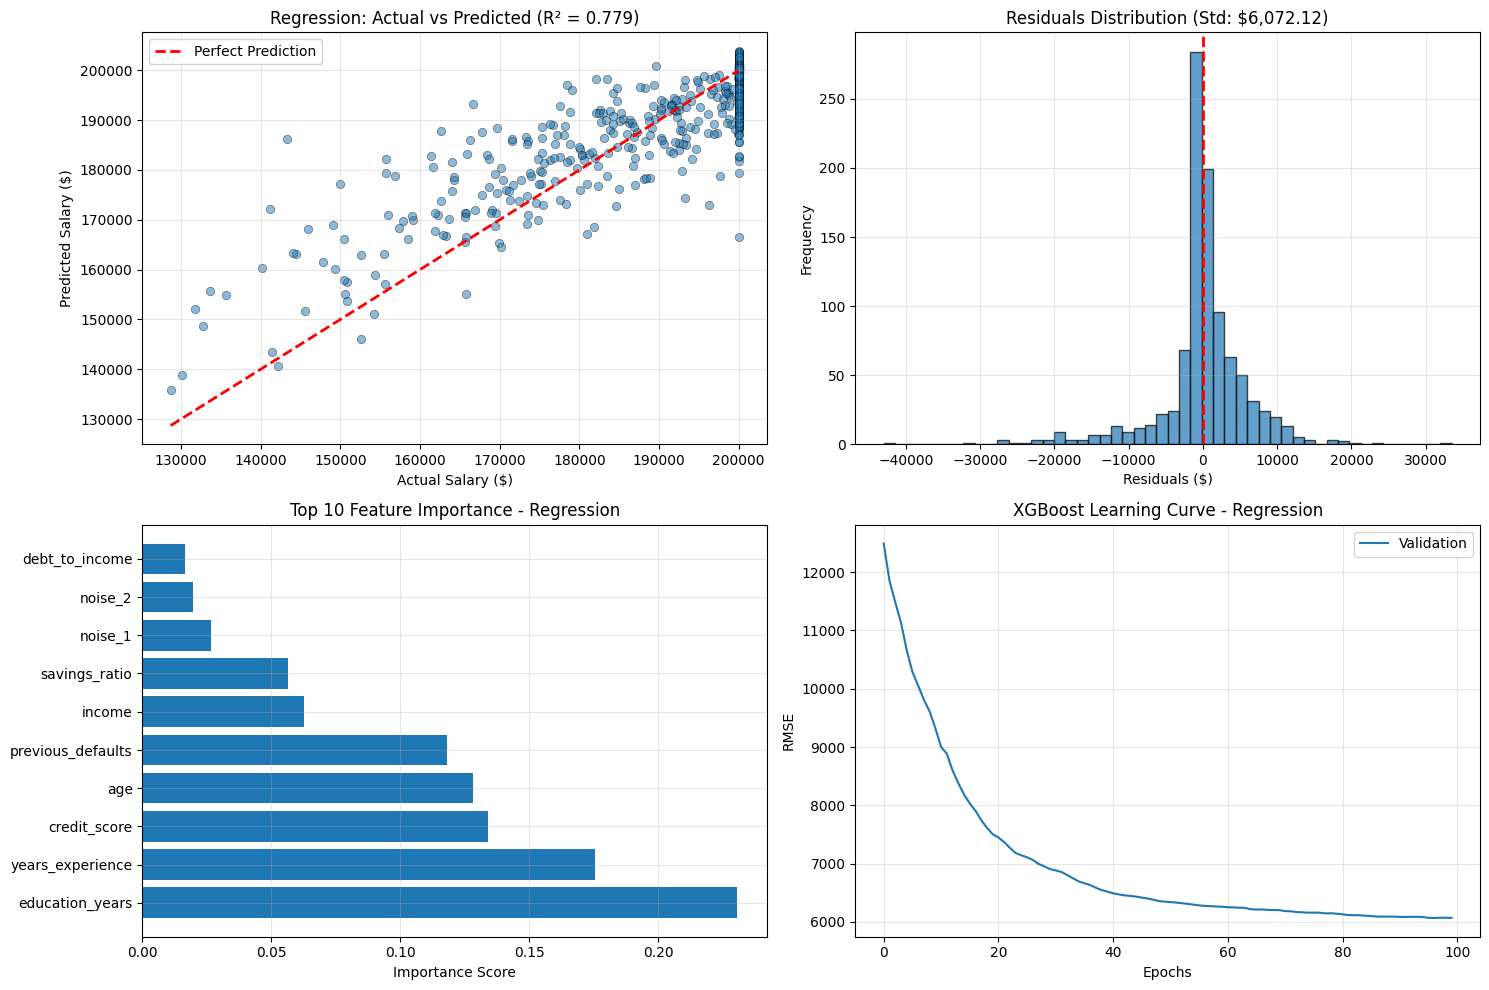

In [16]:
# Visualization for regression
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Actual vs Predicted
axes[0, 0].scatter(y_test_reg, y_pred_reg, alpha=0.5, edgecolors='k', linewidth=0.5)
axes[0, 0].plot([y_test_reg.min(), y_test_reg.max()], 
                [y_test_reg.min(), y_test_reg.max()], 
                'r--', lw=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Salary ($)')
axes[0, 0].set_ylabel('Predicted Salary ($)')
axes[0, 0].set_title(f'Regression: Actual vs Predicted (R² = {r2:.3f})')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Residuals Distribution
residuals = y_test_reg - y_pred_reg
axes[0, 1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Residuals ($)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title(f'Residuals Distribution (Std: ${residuals.std():,.2f})')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Feature Importance
axes[1, 0].barh(feature_importance_reg.head(10)['feature'], 
                feature_importance_reg.head(10)['importance'])
axes[1, 0].set_xlabel('Importance Score')
axes[1, 0].set_title('Top 10 Feature Importance - Regression')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Learning Curves (Training vs Validation)
results = xgb_reg.evals_result()
epochs = len(results['validation_0']['rmse'])
x_axis = range(0, epochs)

axes[1, 1].plot(x_axis, results['validation_0']['rmse'], label='Validation')
axes[1, 1].set_xlabel('Epochs')
axes[1, 1].set_ylabel('RMSE')
axes[1, 1].set_title('XGBoost Learning Curve - Regression')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()